<a href="https://colab.research.google.com/github/lazic7/MSAP/blob/master/LV5_priprema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [141]:
df = pd.read_csv("Invistico_Airline.csv")
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [142]:
df.tail()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
129875,satisfied,Female,disloyal Customer,29,Personal Travel,Eco,1731,5,5,5,...,2,2,3,3,4,4,4,2,0,0.0
129876,dissatisfied,Male,disloyal Customer,63,Personal Travel,Business,2087,2,3,2,...,1,3,2,3,3,1,2,1,174,172.0
129877,dissatisfied,Male,disloyal Customer,69,Personal Travel,Eco,2320,3,0,3,...,2,4,4,3,4,2,3,2,155,163.0
129878,dissatisfied,Male,disloyal Customer,66,Personal Travel,Eco,2450,3,2,3,...,2,3,3,2,3,2,1,2,193,205.0
129879,dissatisfied,Female,disloyal Customer,38,Personal Travel,Eco,4307,3,4,3,...,3,4,5,5,5,3,3,3,185,186.0


In [143]:
df.shape

(129880, 23)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [145]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [146]:
df.mode() # najcesce ponavljane vrijednosti u datasetu

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,39,Business travel,Business,1963,3,4,3,...,4,4,4,4,4,4,4,4,0,0.0


In [147]:
df.isnull().sum()

,0
satisfaction,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0


In [148]:
df.isna().sum()

,0
satisfaction,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0


In [149]:
print(f"Broj redaka prije brisanja: {df.shape[0]}")
df.dropna(inplace=True)
print(f"Broj redaka nakon brisanja: {df.shape[0]}")

Broj redaka prije brisanja: 129880
Broj redaka nakon brisanja: 129487


**Binarizacija** - ovdje se radi binarizacija zato sto kada budemo radili logisticku regresiju vrijednost varijable treba da bude 1 ili 0 a ne string satisfied ili dissatisfied.

In [150]:
df["Satisfied"] = df["satisfaction"].map({
    "satisfied": 1,
    "dissatisfied": 0
})

df["Satisfied"].unique()

array([1, 0])

In [151]:
df["Satisfied"].value_counts()

,count
Satisfied,
1,70882
0,58605


Odabiru se numericke varijable za izracun korelacijske matrice

In [152]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Satisfied'],
      dtype='object')

In [153]:
cols_pearson = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

In [154]:
cols_spearman = [
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Cleanliness",
    "Leg room service",
    "Baggage handling"
]

In [155]:
cols_nominal = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

**Koeficijenti korelacije**

In [156]:
corr_pearson = df[cols_pearson].corr(method="pearson")
corr_pearson

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,-0.249438,-0.009263,-0.011248
Flight Distance,-0.249438,1.000000,0.111608,0.110103
Departure Delay in Minutes,-0.009263,0.111608,1.000000,0.965291
Arrival Delay in Minutes,-0.011248,0.110103,0.965291,1.000000


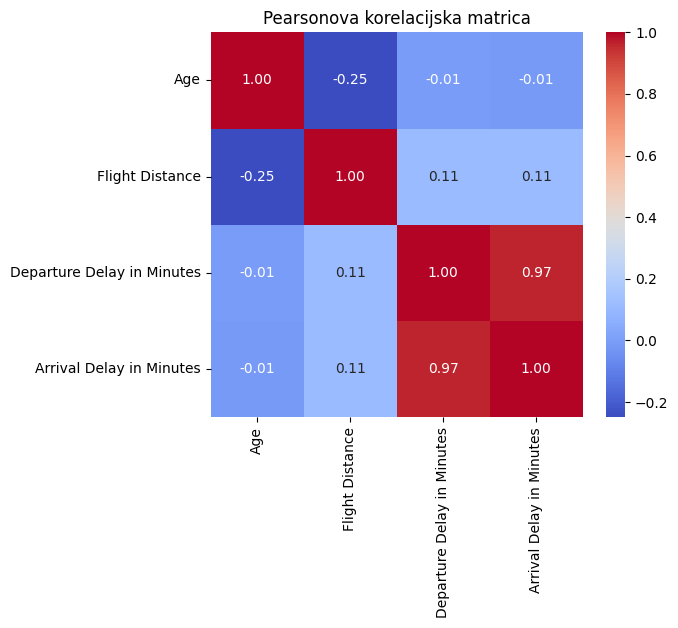

In [157]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearsonova korelacijska matrica")
plt.show()

Iz matrice korelacije numerickih varijabli moze se zakljuciti da postoji slaba negativna korelacija izmedju dobi putnika i flight distance. To hoce kazati da stariji putnici mozda pristaju na kraće letove. Osim toga iz korelacijske matrice moze se zakljuciti da postoji snazna pozitivna korelacija izmedju broja minuta kasnjenja prilikom poletanja i broja minuta kasnjenja prilikom doljetanja aviona. To potencijalno ukazuje da kasnjenje prilikom poljetanja znacajno utjece na kasnjenje i prilikom doljetanja.

In [158]:
corr_spearman = df[cols_spearman].corr(method="spearman")
corr_spearman

,Seat comfort,Inflight entertainment,On-board service,Cleanliness,Leg room service,Baggage handling
Seat comfort,1.000000,0.399236,0.117925,0.106529,0.124021,0.112878
Inflight entertainment,0.399236,1.000000,0.206350,0.146985,0.175311,0.155851
On-board service,0.117925,0.206350,1.000000,0.578680,0.426280,0.555065
Cleanliness,0.106529,0.146985,0.578680,1.000000,0.423042,0.641254
Leg room service,0.124021,0.175311,0.426280,0.423042,1.000000,0.420031
Baggage handling,0.112878,0.155851,0.555065,0.641254,0.420031,1.000000


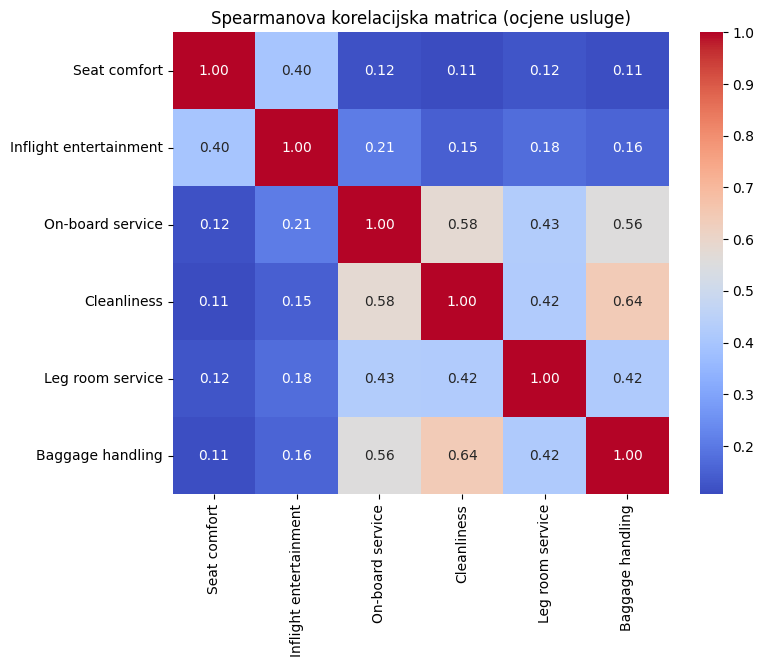

In [159]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearmanova korelacijska matrica (ocjene usluge)")
plt.show()

Iz spearmanove korelacijske matrice mozemo primjetiti da postoji srednja pozitivna veza izmedju inflight entertainment i seat compfort sto dovodi do zakljucka da je inflight entertainment pozitivnije ocjenjen ako su sjedala udobnija. Osim toga vidi se da postoji srednja pozitivna korelacija izmejdu cetiri varijable: cistoca, prostor za noge, on-board serice i baggage handling. To ukazuje da je on-board service bolje ocjenjen ako je cistoca veca, ako postoji vise prostora za noge i ukoliko je prtljaga dobro organizirana.

Za Phi koeficijent je potrebno odabradi jos jednu binarnu varijablu osim Satisfied kako bi se zakljucilo da li postoji povezanost izmedju njih.

In [160]:
df['Type of Travel'].unique()

array(['Personal Travel', 'Business travel'], dtype=object)

In [161]:
df["BusinessTravel"] = df["Type of Travel"].map({
    "Business travel": 1,
    "Personal Travel": 0
})

Radi se kontingencijska tablica

In [162]:
cont = pd.crosstab(df["BusinessTravel"], df["Satisfied"])
cont

Satisfied,0,1
BusinessTravel,,
0,21367,18675
1,37238,52207


In [163]:
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, exp = chi2_contingency(cont)
phi = np.sqrt(chi2 / df.shape[0])

print("Phi koeficijent =", phi)

Phi koeficijent = 0.10889336088858663


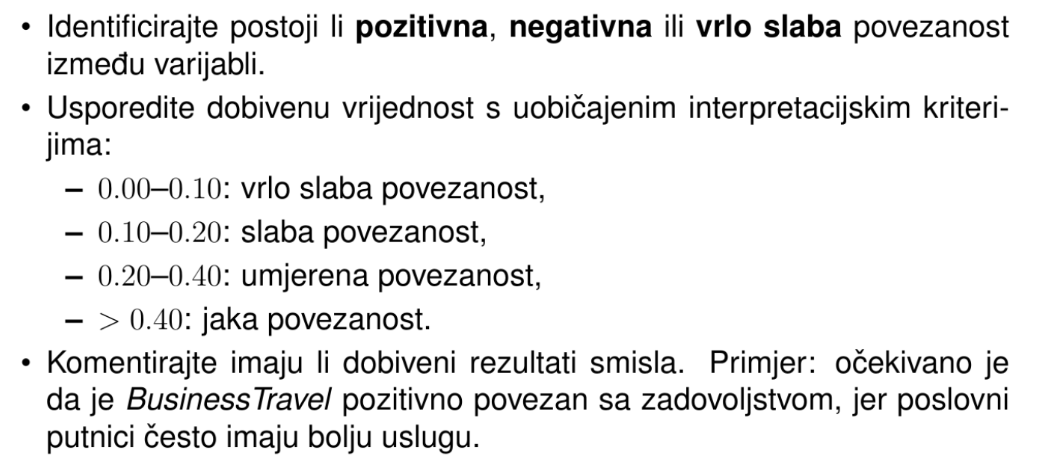

**Multikolinearnost**

In [164]:
features = [
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Cleanliness",
    "Flight Distance",
    "Baggage handling"
]

X_vif = df[features].copy()

In [165]:
X_vif = add_constant(X_vif)

# sigurnosno: pretvori sve u float
X_vif = X_vif.astype(float)

In [166]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,const,22.785962
1,Seat comfort,1.231988
2,Inflight entertainment,1.249749
3,On-board service,1.594020
4,Cleanliness,1.868272
5,Flight Distance,1.004948
6,Baggage handling,1.814818


Sve analizirane varijable imaju prihvatljive VIF vrijednosti, što upućuje na nisku razinu multikolinearnosti i omogućuje njihovu upotrebu u regresijskom modelu.

**Logistička regresija**

In [167]:
y = df["Satisfied"]

In [168]:
features = [
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Cleanliness",
    "Baggage handling",
    "Flight Distance"
]

X = df[features]

Svi prediktori:

numerički / ordinalni

bez multikolinearnosti

interpretabilni

In [169]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=features, index=X.index)

Numeričke varijable standardizirane su kako bi se omogućila usporedivost koeficijenata.

In [170]:
X_const = sm.add_constant(X)

In [171]:
logit_model = sm.Logit(y, X_const).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.485502
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Satisfied   No. Observations:               129487
Model:                          Logit   Df Residuals:                   129480
Method:                           MLE   Df Model:                            6
Date:                Tue, 13 Jan 2026   Pseudo R-squ.:                  0.2950
Time:                        18:12:36   Log-Likelihood:                -62866.
converged:                       True   LL-Null:                       -89171.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.2315      0.007     32.928      0.000       0.218      

Likelihood ratio test pokazuje da je logistički regresijski model statistički značajan (p < 0.05)

Vrijednost McFaddenovog Pseudo R² iznosi 0.295, što upućuje na dobru prilagodbu logističkog modela podacima.

Varijabla Seat comfort nije statistički značajan prediktor zadovoljstva putnika (p > 0.05), što sugerira da njezin učinak nije nezavisan od ostalih ocjena usluge uključenih u model.

In [172]:
params = logit_model.params
odds_ratios = np.exp(params)

odds_ratios

,0
const,1.260431
Seat comfort,0.999478
Inflight entertainment,3.714742
On-board service,1.764321
Cleanliness,1.176769
Baggage handling,1.192730
Flight Distance,0.931837


Varijabla Inflight entertainment ima snažan i statistički značajan pozitivan utjecaj na zadovoljstvo putnika. Povećanje ocjene za jednu jedinicu povećava izglede za zadovoljstvo za približno 3.7 puta.

Dulji letovi povezani su s nešto manjom vjerojatnošću zadovoljstva putnika, uz kontrolu kvalitete usluge.

**Višestruka linearna regresija**

In [173]:
y = df["Arrival Delay in Minutes"]

In [174]:
num_features = [
    "Departure Delay in Minutes",
    "Flight Distance",
    "Age"
]

cat_features = [
    "Type of Travel",
    "Class"
]

X = df[num_features + cat_features].copy()

Kategorijske varijable je potrebno enkodirati uz OneHotEncoder. U OLS-u ne moze biti stringova.

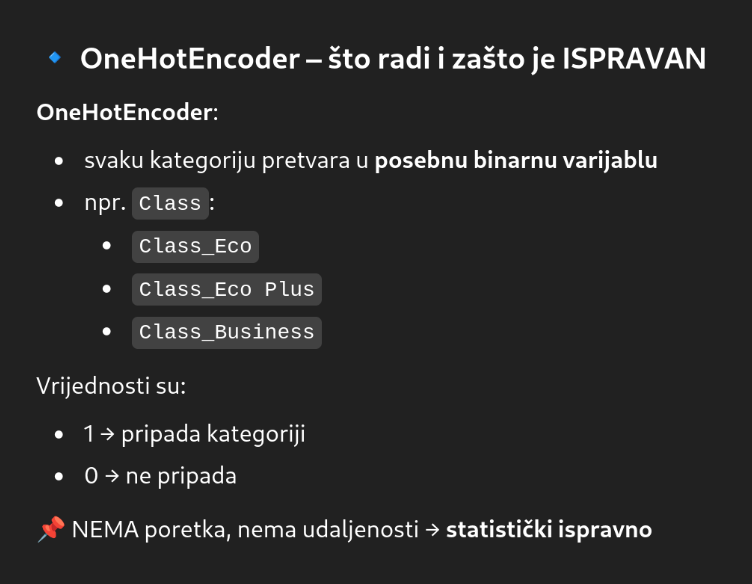

In [175]:
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)
X_encoded.head()

,Departure Delay in Minutes,Flight Distance,Age,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,0,265,65,True,True,False
1,310,2464,47,True,False,False
2,0,2138,15,True,True,False
3,0,623,60,True,True,False
4,0,354,70,True,True,False


VIF racunanje nakon OneHot encodinga.

In [176]:
X_vif = X_encoded.copy()

# pretvori bool u int (0/1)
bool_cols = X_vif.select_dtypes(include="bool").columns
X_vif[bool_cols] = X_vif[bool_cols].astype(int)

In [177]:
X_vif = add_constant(X_vif)

In [178]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,const,18.983150
1,Departure Delay in Minutes,1.014252
2,Flight Distance,1.130994
3,Age,1.107970
4,Type of Travel_Personal Travel,1.446742
5,Class_Eco,1.594015
6,Class_Eco Plus,1.169199


Nakon one-hot kodiranja kategorijskih varijabli izračunat je faktor inflacije varijance (VIF) za sve numeričke i dummy varijable uključene u model. Dobivene VIF vrijednosti su ispod praga od 5, što ukazuje na odsutnost značajne multikolinearnosti. Stoga su sve varijable zadržane u višestrukom linearnom regresijskom modelu.

**OLS model**

In [179]:
X_const = sm.add_constant(X_encoded)

In [182]:
# 1) Pretvori bool u 0/1
X_fix = X_encoded.copy()
bool_cols = X_fix.select_dtypes(include="bool").columns
X_fix[bool_cols] = X_fix[bool_cols].astype(int)

# 2) Dodaj konstantu
X_fix = sm.add_constant(X_fix)

# 3) Pretvori sve u float (najsigurnije za statsmodels)
X_fix = X_fix.astype(float)

# 4) Očisti NaN/inf (za svaki slučaj)
X_fix = X_fix.replace([np.inf, -np.inf], np.nan).dropna()

# 5) Poravnaj y na iste indekse kao X (kritično!)
y_fix = y.loc[X_fix.index].astype(float)

# 6) Fit OLS
ols_model = sm.OLS(y_fix, X_fix).fit()
print(ols_model.summary())


                               OLS Regression Results                               
Dep. Variable:     Arrival Delay in Minutes   R-squared:                       0.932
Model:                                  OLS   Adj. R-squared:                  0.932
Method:                       Least Squares   F-statistic:                 2.950e+05
Date:                      Tue, 13 Jan 2026   Prob (F-statistic):               0.00
Time:                              18:15:02   Log-Likelihood:            -4.8244e+05
No. Observations:                    129487   AIC:                         9.649e+05
Df Residuals:                        129480   BIC:                         9.650e+05
Df Model:                                 6                                         
Covariance Type:                  nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

Višestruki linearni regresijski model objašnjava 93.2% varijabilnosti kašnjenja pri dolasku, što upućuje na vrlo dobru prilagodbu modela podacima. R^2

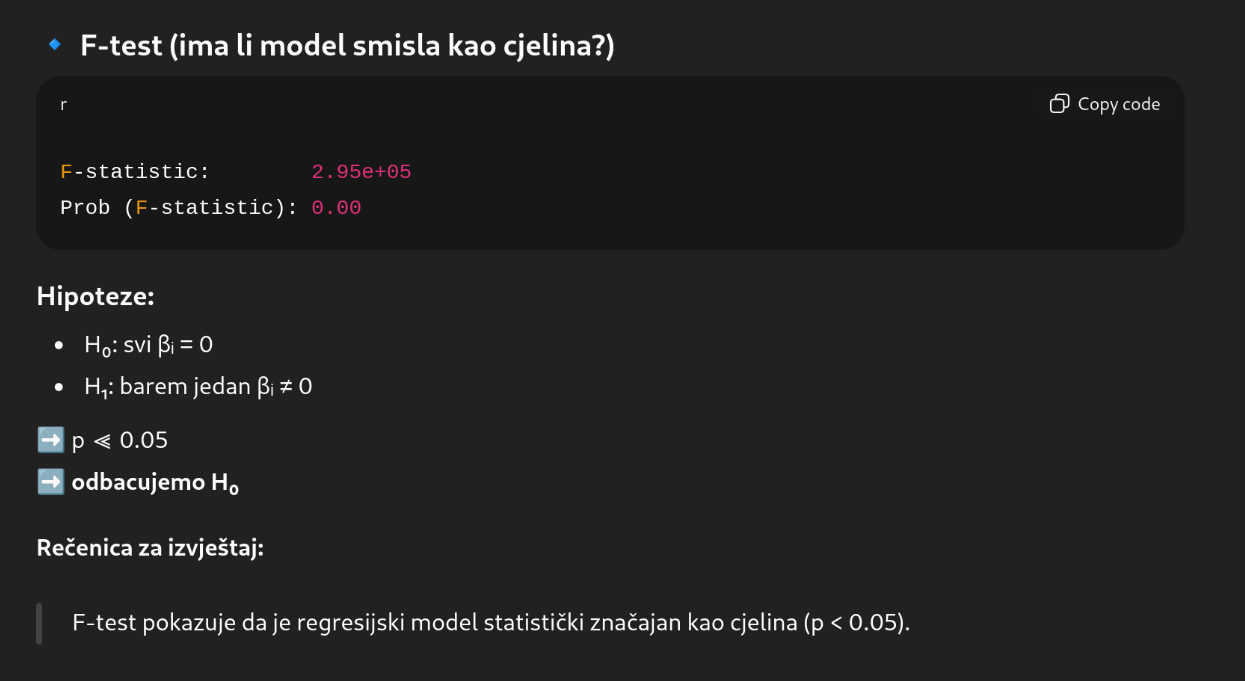

Kašnjenje pri polasku ima snažan i statistički značajan pozitivan utjecaj na kašnjenje pri dolasku. Povećanje kašnjenja pri polasku za jednu minutu povećava očekivano kašnjenje pri dolasku za približno 0.98 minuta.

Dob putnika nije statistički značajan prediktor kašnjenja pri dolasku (p > 0.05).

Putnici na osobnim putovanjima u prosjeku imaju nešto manje kašnjenje pri dolasku u odnosu na poslovne putnike, dok putnici u eco class i eco class plus imaju dodatna kasnjenja

**Analiza reziduala**

In [183]:
df["pred"] = ols_model.fittedvalues
df["resid"] = ols_model.resid

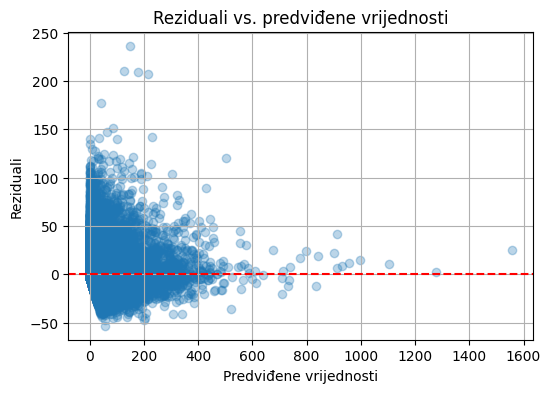

In [184]:
plt.figure(figsize=(6,4))
plt.scatter(df["pred"], df["resid"], alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predviđene vrijednosti")
plt.ylabel("Reziduali")
plt.title("Reziduali vs. predviđene vrijednosti")
plt.grid(True)
plt.show()

većina letova ima:

malo kašnjenje

ali varijabilno ponašanje (otkazivanja, gužve, vremenski uvjeti)

jako velika kašnjenja:

gotovo uvijek uzrokovana konkretnim razlozima

ponašaju se predvidljivije

Graf reziduala u odnosu na predviđene vrijednosti pokazuje oblik lijevka, pri čemu se raspršenost reziduala smanjuje s porastom predviđenog kašnjenja. To upućuje na prisutnost heteroskedastičnosti, odnosno nejednake varijance reziduala. S obzirom na prirodu podataka i velik uzorak, uočena heteroskedastičnost ne narušava značajno pouzdanost procjena regresijskog modela.

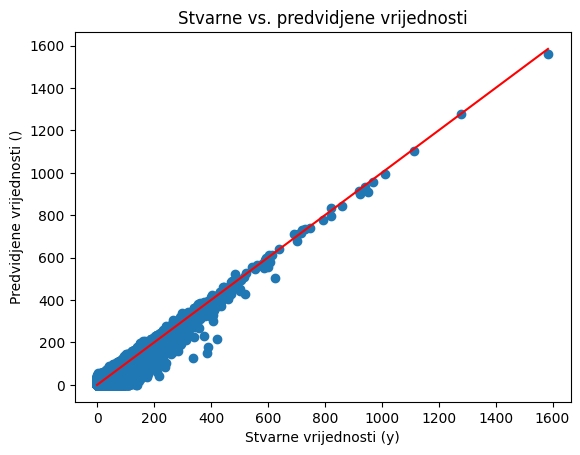

In [188]:
plt.scatter(y, df["pred"])
plt.xlabel("Stvarne vrijednosti (y)")
plt.ylabel("Predvidjene vrijednosti ()")
plt.title("Stvarne vs. predvidjene vrijednosti")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r") # idealna dijagonala
plt.show()